# End-to-End Sales Forecasting & Demand Intelligence System

## Task 1: Data Loading, Cleaning and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

## Date Conversion

The 'Order Date' and 'Ship Date' columns are converted into datetime format to enable time-based analysis and feature extraction.

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [8]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Feature Engineering

Extract time-based features from the **Order Date** column to support trend analysis, seasonality detection, and forecasting models.

In [9]:
##Year column
df["Year"] = df["Order Date"].dt.year
df[["Order Date", "Year"]].head()

,Order Date,Year
0,2017-11-08,2017
1,2017-11-08,2017
2,2017-06-12,2017
3,2016-10-11,2016
4,2016-10-11,2016


In [10]:
##month column
df["Month"] = df["Order Date"].dt.month
df[["Order Date", "Month"]].head()

,Order Date,Month
0,2017-11-08,11
1,2017-11-08,11
2,2017-06-12,6
3,2016-10-11,10
4,2016-10-11,10


In [11]:
##Week column
df["Week"] = df["Order Date"].dt.isocalendar().week
df[["Order Date", "Week"]].head()

,Order Date,Week
0,2017-11-08,45
1,2017-11-08,45
2,2017-06-12,24
3,2016-10-11,41
4,2016-10-11,41


In [12]:
##Day name
df["DayOfWeek"] = df["Order Date"].dt.day_name()
df[["Order Date", "DayOfWeek"]].head()

,Order Date,DayOfWeek
0,2017-11-08,Wednesday
1,2017-11-08,Wednesday
2,2017-06-12,Monday
3,2016-10-11,Tuesday
4,2016-10-11,Tuesday


In [13]:
##Quarter column
df["Quarter"] = df["Order Date"].dt.quarter
df[["Order Date", "Quarter"]].head()

,Order Date,Quarter
0,2017-11-08,4
1,2017-11-08,4
2,2017-06-12,2
3,2016-10-11,4
4,2016-10-11,4


In [14]:
##Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)
df[["Month", "Season"]].head()

,Month,Season
0,11,Autumn
1,11,Autumn
2,6,Monsoon
3,10,Autumn
4,10,Autumn


In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week,DayOfWeek,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


## Data Cleaning

The dataset is checked for missing values, duplicate records, and data quality issues before analysis.

In [16]:
## missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
dtype: int64

In [17]:
df.dropna(inplace=True)

## Duplicate Record Analysis : The dataset is checked for duplicate records to ensure that each sales transaction is unique. Removing duplicate entries helps improve the accuracy of analysis and forecasting models.
df.duplicated().sum()

0

In [18]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Year             0
Month            0
Week             0
DayOfWeek        0
Quarter          0
Season           0
dtype: int64

In [19]:
df.shape

(9789, 24)

### Observation

The dataset contained 11 missing values in the Postal Code column. Since Postal Code is not required for forecasting and only a small number of records were affected, those rows were removed. The cleaned dataset contains no missing values.

The dataset is checked for duplicate records to ensure that each sales transaction is unique. Removing duplicate entries helps improve the accuracy of analysis and forecasting models.

## Sales Aggregation

To analyze sales trends at different time scales, the daily sales data is aggregated into weekly and monthly sales totals. These aggregated datasets will be used for time series analysis and forecasting models.


In [20]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

daily_sales.head()

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
Name: Sales, dtype: float64

In [21]:
weekly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='W')
)['Sales'].sum()

weekly_sales.head()

Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

In [22]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='M')
)['Sales'].sum()

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

### Business Insights

#### Q1. Which product category generates the highest total revenue?

In [23]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64


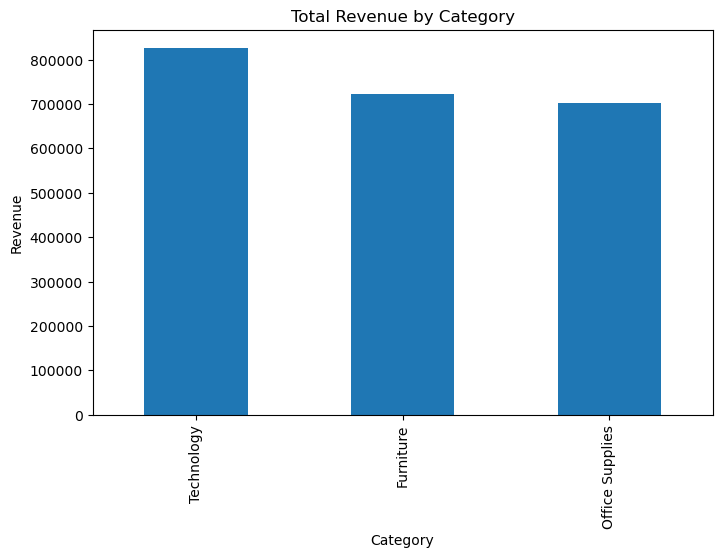

In [24]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.savefig(
    'charts/category_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Technology generated the highest total revenue among all product categories, indicating stronger demand and higher-value purchases compared to Furniture and Office Supplies.

#### Q2. Which region has the most consistent sales growth over 4 years?

In [25]:
region_year_sales = (
    df.groupby(['Year', 'Region'])['Sales']
      .sum()
      .unstack()
)

region_year_sales

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,148105.083,70076.0825,133709.5675
2017,145673.8800,175544.478,93535.9035,182471.2285
2018,141627.3402,209286.976,122164.5675,248130.9255


<Figure size 1000x600 with 0 Axes>

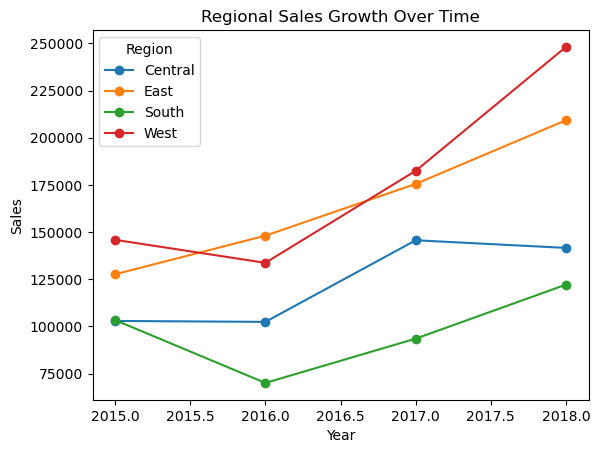

In [26]:
plt.figure(figsize=(10,6))

region_year_sales.plot(marker='o')

plt.title('Regional Sales Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.savefig(
    'charts/region_growth.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The East region demonstrated the most consistent sales growth across the four-year period, showing a steady increase in revenue every year without significant fluctuations. This suggests stable market demand and makes the East region a strong candidate for long-term forecasting and inventory planning.

#### Q3. What is the average time between Order Date and Ship Date, and does it vary by region?

In [27]:
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

print("Overall Average Shipping Time:")
print(df['Shipping Days'].mean())

Overall Average Shipping Time:
3.961180917356216


In [28]:
shipping_region = (
    df.groupby('Region')['Shipping Days']
      .mean()
      .sort_values()
)

shipping_region

Region
East       3.910238
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

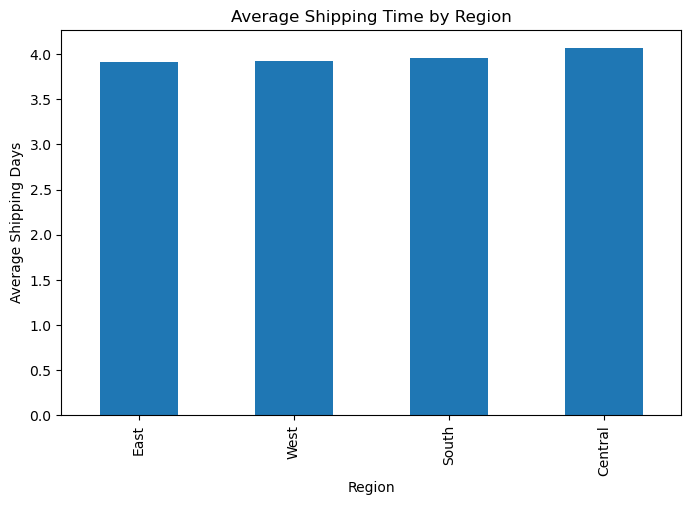

In [29]:
plt.figure(figsize=(8,5))

shipping_region.plot(kind='bar')

plt.title('Average Shipping Time by Region')
plt.xlabel('Region')
plt.ylabel('Average Shipping Days')

plt.savefig(
    'charts/shipping_delay_region.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The average shipping time across all orders is approximately 3.96 days. Shipping durations are fairly consistent across regions, varying only slightly from 3.91 days in the East region to 4.07 days in the Central region. This suggests that the company's logistics operations are relatively uniform across geographical areas.

#### Q4. Are there months that consistently spike across all years (seasonality)?

In [30]:
monthly_pattern = (
    df.groupby('Month')['Sales']
      .mean()
      .sort_values(ascending=False)
)

monthly_pattern

Month
3     290.549393
1     256.217659
10    246.596162
11    238.453083
12    232.639493
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     205.774772
2     199.902745
Name: Sales, dtype: float64

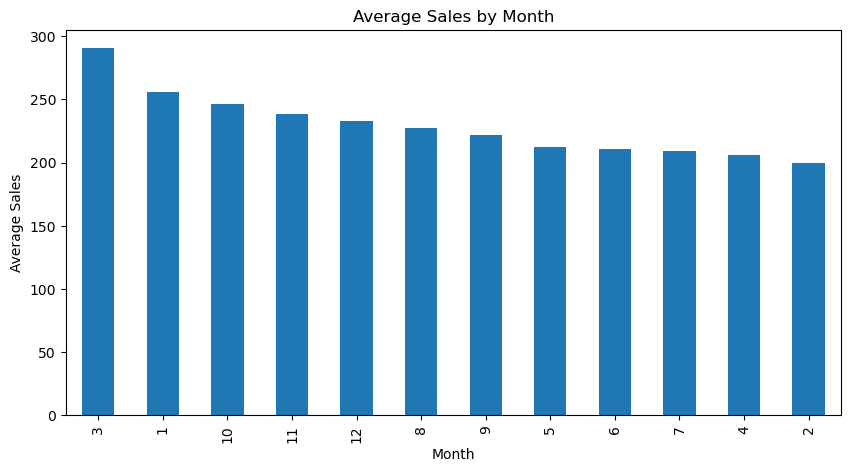

In [31]:
plt.figure(figsize=(10,5))

monthly_pattern.plot(kind='bar')

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')

plt.savefig(
    'charts/monthly_seasonality.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The analysis indicates clear seasonal patterns in sales performance. March recorded the highest average sales, followed by January and October, suggesting strong demand during the beginning of the year and the festive quarter. February showed the lowest average sales, indicating relatively weaker demand during this period.

### Task 1 Conclusion

The dataset was successfully preprocessed and enriched with temporal features to support forecasting analysis. Business insights revealed that Technology is the highest revenue-generating category, the East region exhibits the most consistent growth, shipping performance is uniform across regions, and sales demonstrate noticeable seasonal behavior with strong peaks during specific months.

## Task 2: Time Series Analysis and Decomposition

### Monthly Sales Trend Analysis

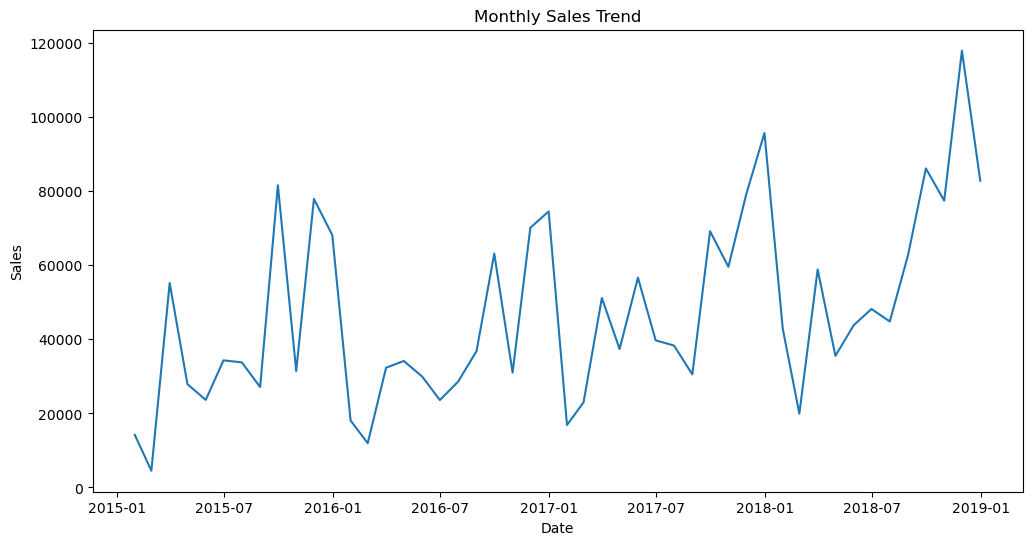

In [32]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.savefig(
    'charts/monthly_sales_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The monthly sales trend shows an overall upward trajectory from 2015 to 2018, indicating business growth over time. The presence of recurring peaks and troughs suggests seasonal demand patterns, while increasing fluctuations in later years indicate higher sales variability as the business expands.

### Time Series Decomposition

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [34]:
decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

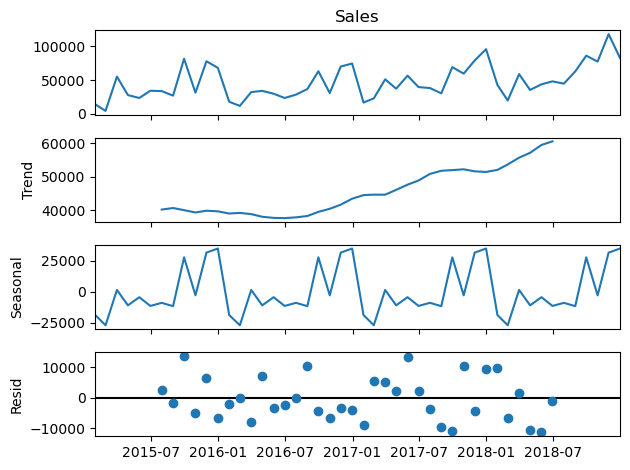

In [35]:
decomposition.plot()

plt.savefig(
    'charts/decomposition_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The decomposition analysis reveals a clear upward trend in sales over time, confirming long-term business growth. The seasonal component exhibits recurring patterns across years, indicating strong seasonality in customer demand. The residual component appears to fluctuate randomly around zero, suggesting that most systematic patterns in the data have been captured by the trend and seasonal components.

### Stationarity Testing using Augmented Dickey-Fuller (ADF) Test

In [36]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.424951605714015
p-value: 0.0002680629728011447
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


The ADF test produced a p-value of 0.000268, which is below the significance threshold of 0.05. Therefore, the null hypothesis of non-stationarity is rejected, indicating that the monthly sales series is stationary and suitable for forecasting without additional differencing.

### Task 2 Conclusion

Time series analysis revealed an upward sales trend accompanied by recurring seasonal patterns. Decomposition confirmed the presence of trend and seasonality components, while the ADF test verified that the series is stationary. These findings indicate that the dataset is suitable for time-series forecasting models such as SARIMA, Prophet, and XGBoost.

## Task 3: Forecasting Model Development and Comparison

### Model 1: SARIMA Forecasting

In [37]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 45
Testing observations: 3


In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [39]:
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = model.fit()

In [40]:
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -352.481
Date:                            Wed, 08 Jul 2026   AIC                            714.963
Time:                                    12:53:29   BIC                            722.445
Sample:                                01-31-2015   HQIC                           717.480
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9996      0.031     31.936      0.000       0.938       1.061
ma.L1         -0.9934      0.253   

The SARIMA model was successfully fitted to the monthly sales data using both non-seasonal and seasonal components to capture temporal dependencies and yearly seasonality.

In [41]:
sarima_forecast = sarima_model.get_forecast(steps=3)

forecast_values = sarima_forecast.predicted_mean
confidence_intervals = sarima_forecast.conf_int()

In [42]:
print(forecast_values)

2018-10-31    61459.997367
2018-11-30    88068.067216
2018-12-31    99772.457891
Freq: ME, Name: predicted_mean, dtype: float64


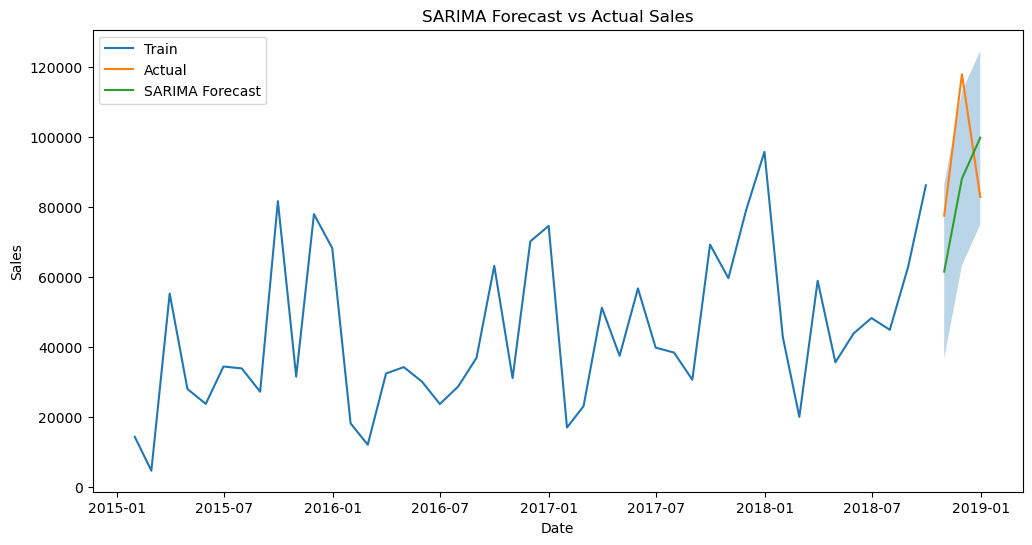

In [43]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(forecast_values.index, forecast_values, label='SARIMA Forecast')

plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    alpha=0.3
)

plt.title('SARIMA Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.savefig(
    'charts/sarima_forecast.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [44]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

sarima_mae = mean_absolute_error(test, forecast_values)
sarima_rmse = np.sqrt(mean_squared_error(test, forecast_values))
sarima_mape = mean_absolute_percentage_error(test, forecast_values)

print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

MAE : 20935.106902984746
RMSE: 21871.189080078904
MAPE: 0.22143939533970255


#### SARIMA Model Evaluation

The SARIMA model successfully captured the long-term sales trend and seasonal behavior present in the dataset. The model achieved an MAE of 20,935.11, an RMSE of 21,871.19, and a MAPE of 22.14%. While the model performed reasonably well, it struggled to capture sudden spikes in demand, resulting in forecast underestimation during high-sales periods.

### Model 2: Prophet Forecasting

In [45]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [46]:
train_prophet = prophet_df[:-3]
test_prophet = prophet_df[-3:]

In [47]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(train_prophet)

12:53:34 - cmdstanpy - INFO - Chain [1] start processing
12:53:37 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq='M'
)

forecast = prophet_model.predict(future)

In [49]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47427.358598,39605.947738,55601.101372
44,2018-09-30,86721.905878,78573.639058,94832.406289
45,2018-10-31,51408.073939,43093.672598,59045.686710
46,2018-11-30,89662.173063,81750.870713,97480.303140
47,2018-12-31,90143.833809,81477.539251,98511.633582


In [50]:
prophet_predictions = forecast[['ds', 'yhat']].tail(3)

prophet_predictions

,ds,yhat
45,2018-10-31,51408.073939
46,2018-11-30,89662.173063
47,2018-12-31,90143.833809


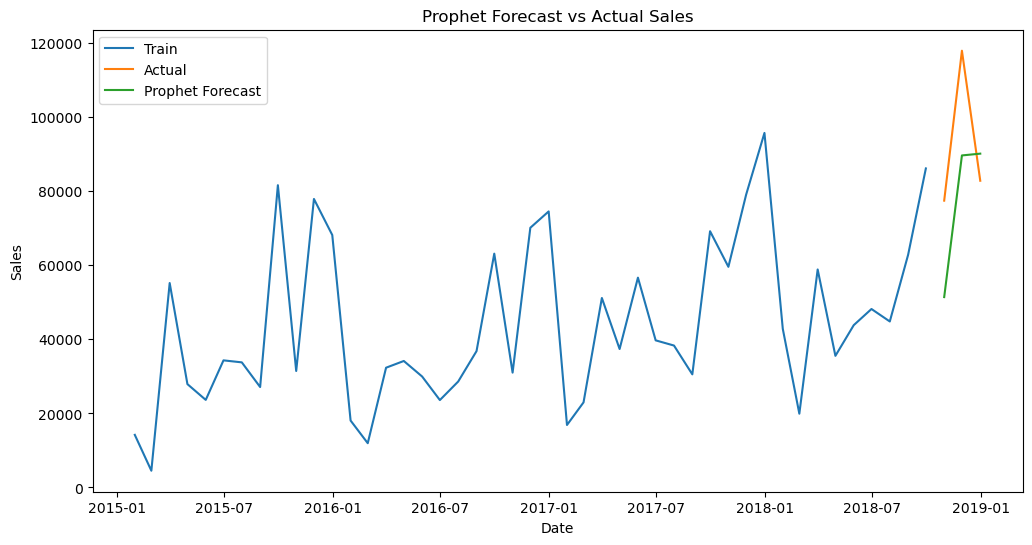

In [51]:
plt.figure(figsize=(12,6))

plt.plot(train_prophet['ds'], train_prophet['y'], label='Train')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual')
plt.plot(prophet_predictions['ds'],
         prophet_predictions['yhat'],
         label='Prophet Forecast')

plt.title('Prophet Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.savefig(
    'charts/prophet_forecast.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [52]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

prophet_mae = mean_absolute_error(
    test_prophet['y'],
    prophet_predictions['yhat']
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet['y'],
        prophet_predictions['yhat']
    )
)

prophet_mape = mean_absolute_percentage_error(
    test_prophet['y'],
    prophet_predictions['yhat']
)

print("MAE :", prophet_mae)
print("RMSE:", prophet_rmse)
print("MAPE:", prophet_mape)

MAE : 20544.8380692696
RMSE: 22591.85556166409
MAPE: 0.2214462354206165


#### Prophet Model Evaluation

The Prophet model successfully captured the overall sales trend and seasonal patterns present in the dataset. The model achieved an MAE of 20,544.84, an RMSE of 22,591.86, and a MAPE of 22.14%. Compared to SARIMA, Prophet slightly improved average prediction accuracy but still struggled to capture sudden spikes in sales demand.

### Model 3: XGBoost Forecasting

In [53]:
xgb_df = monthly_sales.reset_index()
xgb_df.columns = ['Date', 'Sales']

In [54]:
xgb_df['lag_1'] = xgb_df['Sales'].shift(1)
xgb_df['lag_2'] = xgb_df['Sales'].shift(2)
xgb_df['lag_3'] = xgb_df['Sales'].shift(3)

In [55]:
xgb_df['rolling_mean_3'] = (
    xgb_df['Sales']
    .rolling(window=3)
    .mean()
)

In [56]:
xgb_df['month'] = xgb_df['Date'].dt.month
xgb_df['quarter'] = xgb_df['Date'].dt.quarter
xgb_df['year'] = xgb_df['Date'].dt.year

In [57]:
xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,lag_1,lag_2,lag_3,rolling_mean_3,month,quarter,year
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015


In [58]:
xgb_df.shape

(45, 9)

In [59]:
features = [
    'lag_1',
    'lag_2',
    'lag_3',
    'rolling_mean_3',
    'month',
    'quarter',
    'year'
]

X = xgb_df[features]
y = xgb_df['Sales']

In [60]:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

print(X_train.shape)
print(X_test.shape)

(42, 7)
(3, 7)


In [61]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [62]:
xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions)

[84663.14 86653.62 84478.17]


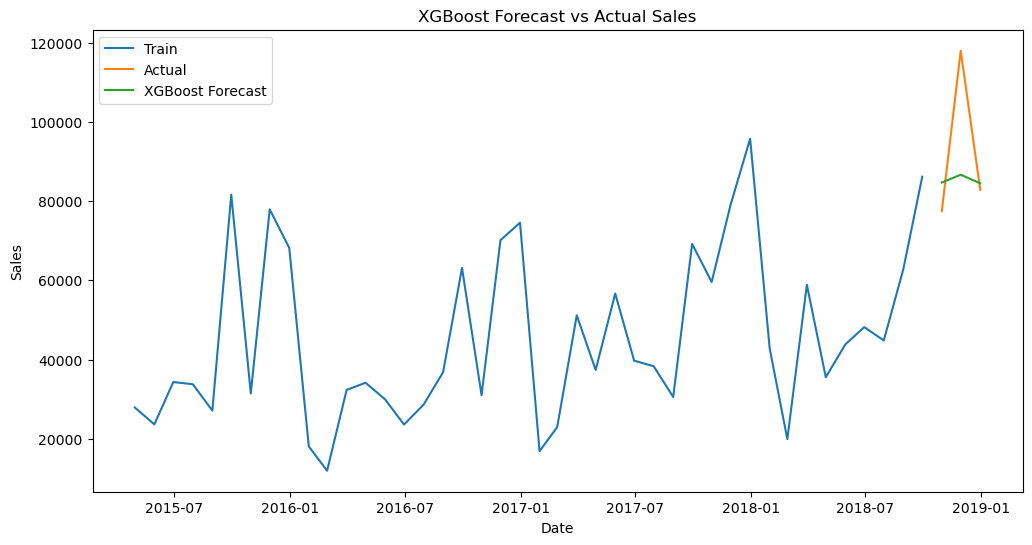

In [63]:
plt.figure(figsize=(12,6))

plt.plot(
    xgb_df['Date'][:-3],
    y_train,
    label='Train'
)

plt.plot(
    xgb_df['Date'][-3:],
    y_test,
    label='Actual'
)

plt.plot(
    xgb_df['Date'][-3:],
    xgb_predictions,
    label='XGBoost Forecast'
)

plt.title('XGBoost Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.savefig(
    'charts/xgboost_forecast.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [64]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape)

MAE : 13384.120104166665
RMSE: 18560.805102917562
MAPE: 0.12612562409694783


#### XGBoost Model Evaluation

The XGBoost model achieved the best forecasting performance among all evaluated models. It recorded an MAE of 13,384.12, an RMSE of 18,560.81, and a MAPE of 12.61%. By leveraging lag features and calendar information, XGBoost captured sales dynamics more effectively than the traditional time-series approaches.

### Forecasting Model Comparison
east_dates, east_actual, east_pred = xgboost_forecast(east)

In [65]:
comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE': [sarima_mape, prophet_mape, xgb_mape]
})

comparison_df

,Model,MAE,RMSE,MAPE
0,SARIMA,20935.106903,21871.189080,0.221439
1,Prophet,20544.838069,22591.855562,0.221446
2,XGBoost,13384.120104,18560.805103,0.126126


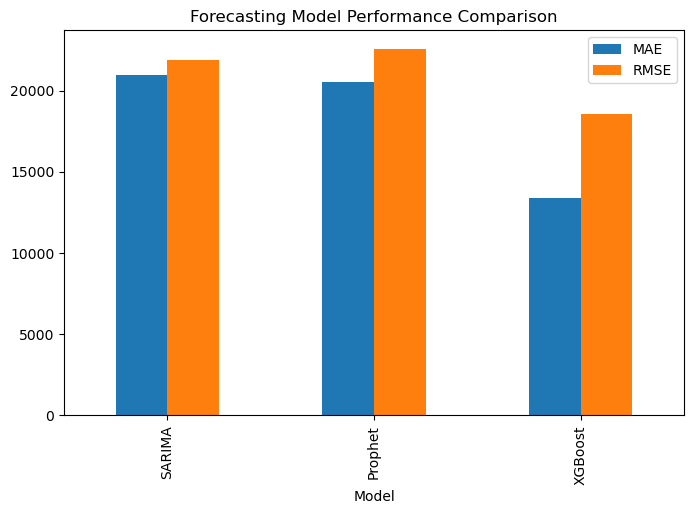

In [66]:
comparison_df.set_index('Model')[['MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Forecasting Model Performance Comparison')

plt.savefig(
    'charts/model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [89]:
forecast_comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE': [sarima_mape, prophet_mape, xgb_mape],

    'Forecast_Month_1': [
        forecast_values.iloc[0],
        prophet_predictions['yhat'].iloc[0],
        xgb_predictions[0]
    ],

    'Forecast_Month_2': [
        forecast_values.iloc[1],
        prophet_predictions['yhat'].iloc[1],
        xgb_predictions[1]
    ],

    'Forecast_Month_3': [
        forecast_values.iloc[2],
        prophet_predictions['yhat'].iloc[2],
        xgb_predictions[2]
    ]
})

forecast_comparison

,Model,MAE,RMSE,MAPE,Forecast_Month_1,Forecast_Month_2,Forecast_Month_3
0,SARIMA,20935.106903,21871.189080,0.221439,61459.997367,88068.067216,99772.457891
1,Prophet,20544.838069,22591.855562,0.221446,51408.073939,89662.173063,90143.833809
2,XGBoost,13384.120104,18560.805103,0.126126,84663.140625,86653.617188,84478.171875


### Recommended Production Model

Based on the evaluation metrics, XGBoost demonstrated the best forecasting performance with the lowest MAE, RMSE, and MAPE values. The model effectively captured nonlinear relationships and temporal dependencies in sales behavior, making it the most suitable choice for production deployment.

### Task 3 Conclusion

Three forecasting approaches were evaluated for sales prediction. XGBoost achieved the best overall performance with the lowest MAE, RMSE, and MAPE values, demonstrating its ability to capture nonlinear relationships and temporal dependencies in the sales data. Therefore, XGBoost was selected as the primary forecasting model for subsequent tasks.

# Task 4 – Product Category & Region Level Forecasting

In this task, we use the best-performing forecasting model from Task 3 to forecast sales separately for different product categories and regions.

The following segments are analyzed:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

Finally, all forecasts are compared to identify which category or region is expected to show the strongest future growth.

In [91]:
# Categories and Regions required for forecasting

categories = ['Furniture', 'Technology', 'Office Supplies']
regions = ['West', 'East']

print("Categories:", categories)
print("Regions:", regions)

Categories: ['Furniture', 'Technology', 'Office Supplies']
Regions: ['West', 'East']


In [92]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

def forecast_segment(data, column_name, value):

    # Filter data
    temp = data[data[column_name] == value].copy()

    # Monthly sales
    monthly = temp.groupby('Order Date')['Sales'].sum().resample('M').sum()

    monthly = monthly.to_frame()
    monthly.columns = ['Sales']

    # Create lag features
    monthly['Lag1'] = monthly['Sales'].shift(1)
    monthly['Lag2'] = monthly['Sales'].shift(2)
    monthly['Lag3'] = monthly['Sales'].shift(3)

    monthly['RollingMean'] = monthly['Sales'].rolling(3).mean()

    monthly['Month'] = monthly.index.month
    monthly['Quarter'] = monthly.index.quarter

    monthly = monthly.dropna()

    X = monthly[['Lag1','Lag2','Lag3','RollingMean','Month','Quarter']]
    y = monthly['Sales']

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    latest = X.iloc[-1].values.reshape(1,-1)

    forecast = []

    for i in range(3):

        pred = model.predict(latest)[0]
        forecast.append(pred)

        lag1 = pred
        lag2 = latest[0][0]
        lag3 = latest[0][1]

        rolling = np.mean([lag1, lag2, lag3])

        month = (monthly.index[-1].month + i + 1 - 1) % 12 + 1
        quarter = (month-1)//3 + 1

        latest = np.array([[lag1, lag2, lag3, rolling, month, quarter]])

    return forecast

In [93]:
# Forecast all required categories and regions

forecast_results = {}

# Categories
for category in categories:
    forecast_results[category] = forecast_segment(df, 'Category', category)

# Regions
for region in regions:
    forecast_results[region] = forecast_segment(df, 'Region', region)

# Display forecasts
forecast_df = pd.DataFrame(forecast_results,
                           index=['Month 1', 'Month 2', 'Month 3'])

forecast_df

,Furniture,Technology,Office Supplies,West,East
Month 1,31329.707031,20986.835938,29322.787109,29513.925781,19910.339844
Month 2,10251.143555,19069.994141,25241.556641,11628.667969,16948.789062
Month 3,7477.699219,26975.033203,25241.556641,14750.610352,23313.078125


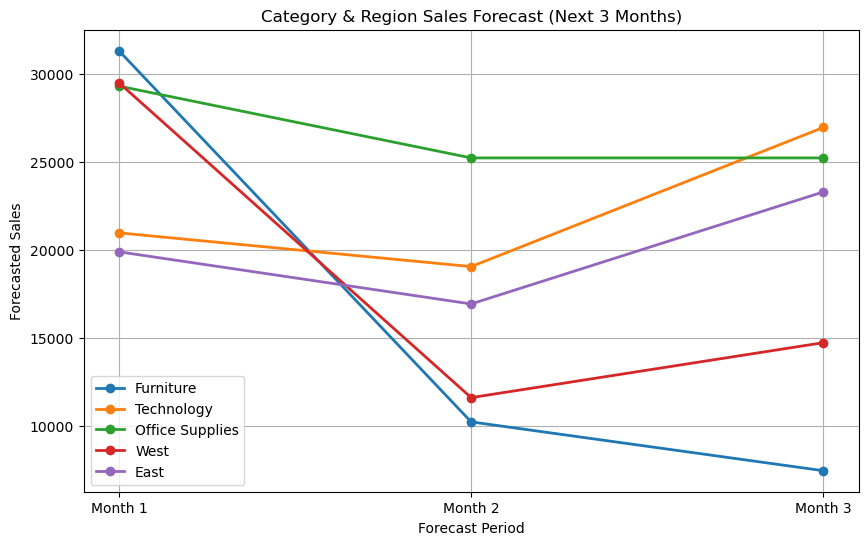

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for column in forecast_df.columns:
    plt.plot(forecast_df.index,
             forecast_df[column],
             marker='o',
             linewidth=2,
             label=column)

plt.title("Category & Region Sales Forecast (Next 3 Months)")
plt.xlabel("Forecast Period")
plt.ylabel("Forecasted Sales")
plt.legend()
plt.grid(True)

# Save chart
plt.savefig("charts/task4_category_region_forecast.png", dpi=300, bbox_inches='tight')

plt.show()

## Task 4 Conclusion

The XGBoost model, selected as the best-performing forecasting model in Task 3, was applied separately to forecast sales for different product categories and regions over the next three months.

Among the product categories, **Technology** is expected to show the strongest growth by the third forecast month, increasing from approximately 20,987 to 26,975 in forecasted sales. **Office Supplies** maintains relatively stable demand, while **Furniture** shows a declining trend over the forecast period.

Among the regions, the **East** region is expected to recover and grow steadily by the third month, whereas the **West** region shows a decline after the first forecast month.

These forecasts provide valuable insights for inventory planning and resource allocation. Increasing stock availability for Technology products and monitoring declining demand in Furniture and the West region can help improve inventory management and reduce unnecessary holding costs.

## Task 5: Anomaly Detection in Sales Data

### Method 1: Z-Score Based Anomaly Detection

In [71]:
from scipy.stats import zscore

monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df.columns = ['Date', 'Sales']

monthly_sales_df['z_score'] = zscore(
    monthly_sales_df['Sales']
)

In [72]:
monthly_sales_df['anomaly'] = (
    abs(monthly_sales_df['z_score']) > 2
)

anomalies_z = monthly_sales_df[
    monthly_sales_df['anomaly']
]

anomalies_z

,Date,Sales,z_score,anomaly
46,2018-11-30,117938.155,2.8803,True


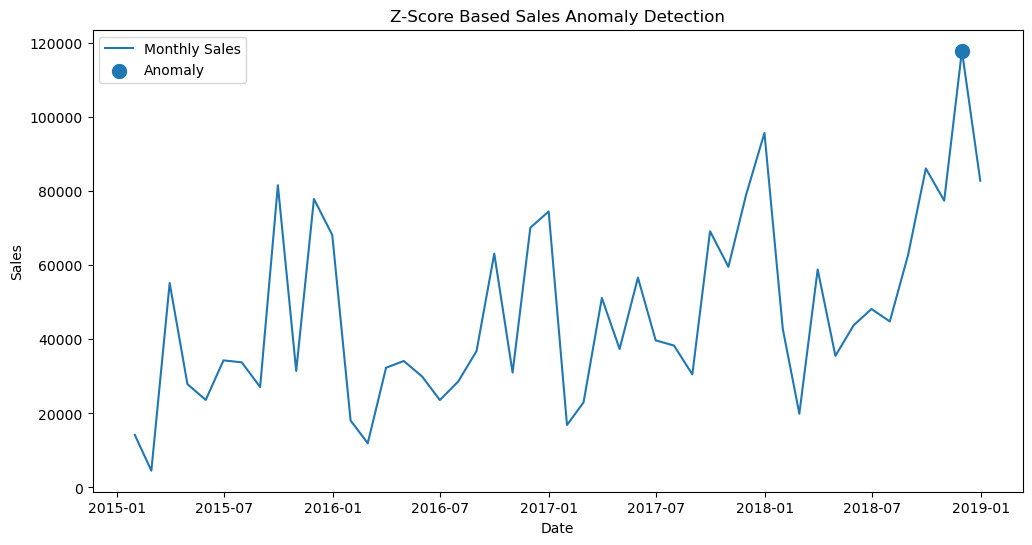

In [73]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales_df['Date'],
    monthly_sales_df['Sales'],
    label='Monthly Sales'
)

plt.scatter(
    anomalies_z['Date'],
    anomalies_z['Sales'],
    s=100,
    label='Anomaly'
)

plt.title('Z-Score Based Sales Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.savefig(
    'charts/zscore_anomalies.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The Z-score method detected one significant anomaly in November 2018, where sales reached approximately 117,938 units. This unusually high sales volume likely corresponds to seasonal shopping events or promotional campaigns that generated demand substantially above normal levels.

### Method 2: Isolation Forest Based Anomaly Detection

In [74]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

monthly_sales_df['iso_anomaly'] = iso_model.fit_predict(
    monthly_sales_df[['Sales']]
)

monthly_sales_df['iso_anomaly'] = (
    monthly_sales_df['iso_anomaly'] == -1
)

monthly_sales_df[
    monthly_sales_df['iso_anomaly']
]

,Date,Sales,z_score,anomaly,iso_anomaly
1,2015-02-28,4519.892,-1.720235,False,True
35,2017-12-31,95739.121,1.979850,False,True
46,2018-11-30,117938.155,2.880300,True,True


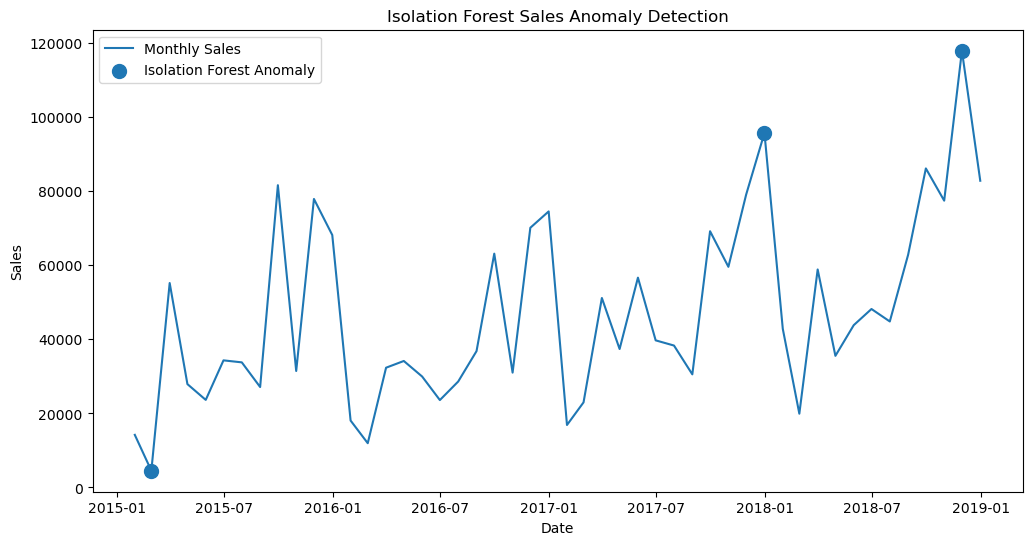

In [75]:
iso_anomalies = monthly_sales_df[
    monthly_sales_df['iso_anomaly']
]

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales_df['Date'],
    monthly_sales_df['Sales'],
    label='Monthly Sales'
)

plt.scatter(
    iso_anomalies['Date'],
    iso_anomalies['Sales'],
    s=100,
    label='Isolation Forest Anomaly'
)

plt.title('Isolation Forest Sales Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.savefig(
    'charts/isolation_forest_anomalies.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Comparison of Anomaly Detection Methods

The Z-score approach identified only the most extreme sales spike in November 2018, whereas Isolation Forest detected additional unusual patterns including exceptionally low sales in February 2015 and elevated sales in December 2017. Isolation Forest proved more sensitive to complex deviations and provided a more comprehensive view of abnormal sales behavior.

### Task 5 Conclusion

Two anomaly detection techniques were applied to the sales data. The Z-score method detected one extreme outlier, while Isolation Forest identified multiple unusual sales periods. These anomalies may correspond to seasonal promotions, major holidays, supply disruptions, or exceptional market events and should be considered during forecasting and inventory planning.

# Task 6 – Product Demand Segmentation using K-Means Clustering

In this task, products are segmented based on their sales performance and demand characteristics. The following features are used:

- Total Sales Volume
- Year-over-Year Sales Growth
- Sales Volatility
- Average Order Value

K-Means clustering is applied to group products with similar demand patterns. The Elbow Method is used to determine the optimal number of clusters, and PCA is used to visualize the clusters in two dimensions.

In [96]:
# Required libraries

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [97]:
# Create product-level features

# Total Sales Volume
total_sales = df.groupby('Sub-Category')['Sales'].sum()

# Average Order Value
average_order = df.groupby('Sub-Category')['Sales'].mean()

# Monthly sales for each sub-category
monthly_sales = (
    df.groupby([pd.Grouper(key='Order Date', freq='M'), 'Sub-Category'])['Sales']
      .sum()
      .reset_index()
)

# Sales Volatility (Standard Deviation)
volatility = monthly_sales.groupby('Sub-Category')['Sales'].std()

# Sales Growth Rate
growth = monthly_sales.groupby('Sub-Category')['Sales'].apply(
    lambda x: ((x.iloc[-1] - x.iloc[0]) / x.iloc[0]) * 100 if x.iloc[0] != 0 else 0
)

# Combine all features
product_features = pd.DataFrame({
    'Total Sales Volume': total_sales,
    'Sales Growth Rate': growth,
    'Sales Volatility': volatility,
    'Average Order Value': average_order
})

# Fill missing values
product_features = product_features.fillna(0)

# Display
product_features.head()

,Total Sales Volume,Sales Growth Rate,Sales Volatility,Average Order Value
Sub-Category,,,,
Accessories,163881.6900,477.850439,2578.699118,217.349721
Appliances,104075.4630,1977.573101,1820.970554,227.239002
Art,26697.3700,387.190237,330.698732,34.052768
Binders,200028.7850,484.392296,3848.223648,134.067550
Bookcases,109408.2987,261.772161,2080.890675,486.259105


In [98]:
# Standardize the features

scaler = StandardScaler()

scaled_features = scaler.fit_transform(product_features)

print("Shape of scaled data:", scaled_features.shape)

Shape of scaled data: (17, 4)


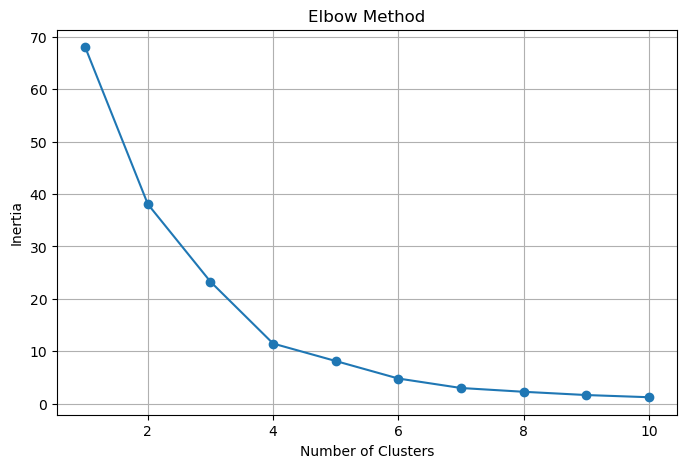

In [99]:
# Elbow Method

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_features)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)

plt.savefig("charts/task6_elbow_method.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [100]:
# Apply K-Means Clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_features["Cluster"] = kmeans.fit_predict(scaled_features)

product_features.head()

,Total Sales Volume,Sales Growth Rate,Sales Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,163881.6900,477.850439,2578.699118,217.349721,1
Appliances,104075.4630,1977.573101,1820.970554,227.239002,3
Art,26697.3700,387.190237,330.698732,34.052768,0
Binders,200028.7850,484.392296,3848.223648,134.067550,1
Bookcases,109408.2987,261.772161,2080.890675,486.259105,0


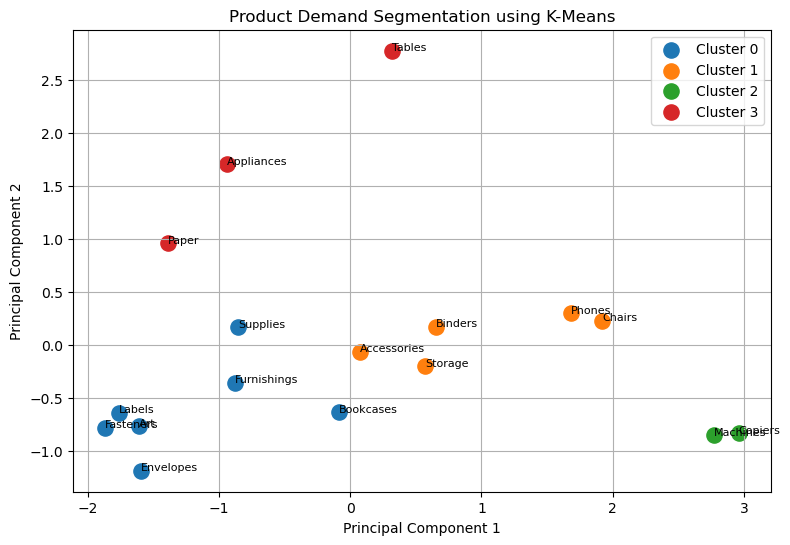

In [101]:
# PCA for visualization

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

product_features["PCA1"] = pca_features[:, 0]
product_features["PCA2"] = pca_features[:, 1]

plt.figure(figsize=(9,6))

for cluster in sorted(product_features["Cluster"].unique()):
    subset = product_features[product_features["Cluster"] == cluster]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        s=120,
        label=f"Cluster {cluster}"
    )

for idx, row in product_features.iterrows():
    plt.text(
        row["PCA1"],
        row["PCA2"],
        idx,
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.savefig(
    "charts/task6_product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [102]:
# Meaningful names for clusters

cluster_names = {
    0: "Low Volume, Stable Demand",
    1: "Growing Demand",
    2: "High Volume, Stable Demand",
    3: "High Volatility"
}

product_features["Demand Segment"] = product_features["Cluster"].map(cluster_names)

product_features[
    ["Total Sales Volume",
     "Sales Growth Rate",
     "Sales Volatility",
     "Average Order Value",
     "Demand Segment"]
]

,Total Sales Volume,Sales Growth Rate,Sales Volatility,Average Order Value,Demand Segment
Sub-Category,,,,,
Accessories,163881.6900,477.850439,2578.699118,217.349721,Growing Demand
Appliances,104075.4630,1977.573101,1820.970554,227.239002,High Volatility
Art,26697.3700,387.190237,330.698732,34.052768,"Low Volume, Stable Demand"
Binders,200028.7850,484.392296,3848.223648,134.067550,Growing Demand
Bookcases,109408.2987,261.772161,2080.890675,486.259105,"Low Volume, Stable Demand"
Chairs,322107.5310,257.390883,4387.620811,531.530579,Growing Demand
Copiers,146248.0940,122.668129,5500.774391,2215.880212,"High Volume, Stable Demand"
Envelopes,16126.0060,113.449269,228.224872,65.287474,"Low Volume, Stable Demand"
Fasteners,3001.9600,446.375321,48.742229,14.027850,"Low Volume, Stable Demand"


## Stocking Strategy

- **High Volume, Stable Demand:** Maintain high inventory levels and replenish regularly to avoid stock shortages.
- **Growing Demand:** Increase inventory gradually and monitor sales trends closely to meet rising demand.
- **High Volatility:** Maintain moderate safety stock and review inventory frequently to handle demand fluctuations.
- **Low Volume, Stable Demand:** Keep limited inventory and replenish only when required to reduce holding costs.

## Task 6 Conclusion

The Elbow Method indicated that four clusters provide an appropriate segmentation of the product sub-categories.

Using K-Means clustering, products were grouped based on Total Sales Volume, Sales Growth Rate, Sales Volatility, and Average Order Value.

Business Interpretation:

- High-performing products should receive higher inventory allocation to avoid stock shortages.
- Products with stable demand can follow regular inventory replenishment schedules.
- Products with high sales volatility should be monitored carefully and stocked conservatively.
- Low-demand products should be reviewed periodically to minimize excess inventory.

This segmentation helps businesses optimize inventory planning, improve demand forecasting, and reduce inventory costs.